In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Initiating Harmonic Coherence Training (Two-Phase)...
Epoch 0 (Proliferation) | Friston Loss: 80.1317 | Dense Synapses: 1277
Epoch 100 (Proliferation) | Friston Loss: 57.8995 | Dense Synapses: 3162
Epoch 200 (Pruning) | Friston Loss: 54.0684 | Dense Synapses: 3384
Epoch 300 (Pruning) | Friston Loss: 52.8702 | Dense Synapses: 3413
Epoch 400 (Pruning) | Friston Loss: 51.7178 | Dense Synapses: 3495
Epoch 500 (Pruning) | Friston Loss: 20.9511 | Dense Synapses: 3576


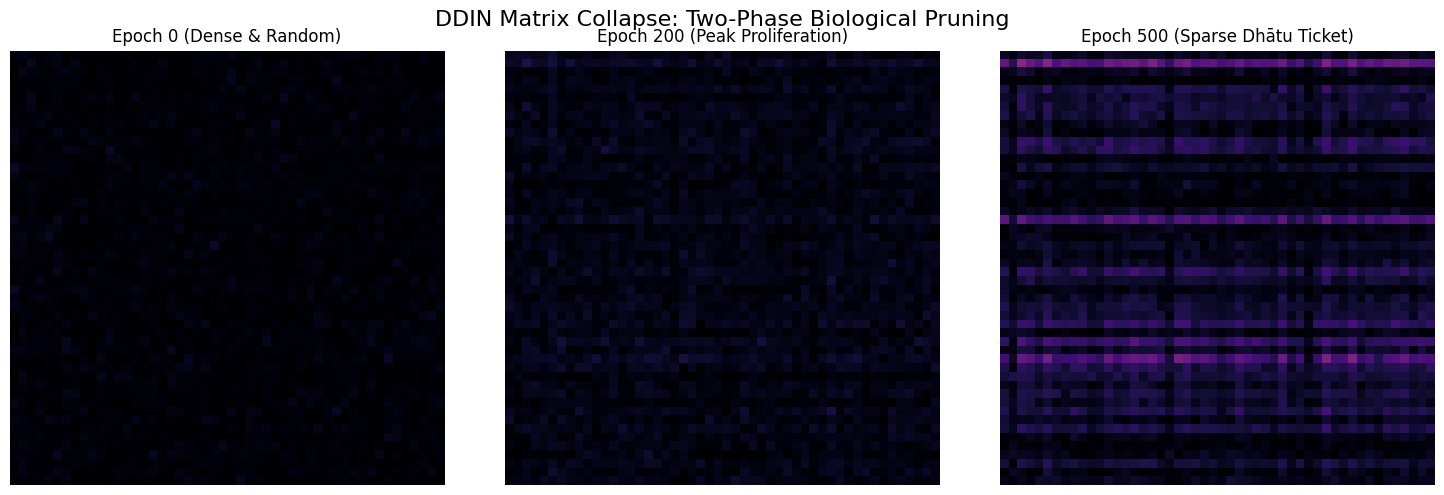

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Define the model (with nonlinearity + smaller hidden dim)
# ---------------------------------------------------------
class ResonanceModel(nn.Module):
    def __init__(self, hidden_dim=64):  # tractable size
        super().__init__()
        self.W = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
    
    def forward(self, x, stimulus):
        # Add nonlinearity to stabilize dynamics
        return torch.tanh(torch.matmul(x, self.W) + stimulus)

# Initialize model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResonanceModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ---------------------------------------------------------
# 2. Generate dataset
# ---------------------------------------------------------
seq_len = 100
t = torch.linspace(0, 10, seq_len).to(device)

stimulus_signal = torch.sin(t).unsqueeze(1).repeat(1, 64)
target_signal   = torch.cos(t).unsqueeze(1).repeat(1, 64)

# ---------------------------------------------------------
# 3. Training loop (Two-Phase Biological Pruning)
# ---------------------------------------------------------
epochs = 500
matrix_snapshots = []
matrix_snapshots.append(model.W.detach().cpu().numpy().copy())

print("Initiating Harmonic Coherence Training (Two-Phase)...")

for epoch in range(epochs + 1):
    optimizer.zero_grad()
    x_state = torch.zeros(1, 64).to(device)
    
    loss_friston_total = 0.0
    all_states = []
    
    # Run the continuous sequence
    for i in range(seq_len):
        x_state = model(x_state, stimulus_signal[i])
        loss_friston_total += F.mse_loss(x_state, target_signal[i].unsqueeze(0))
        all_states.append(x_state)
    
    # Mean Prāṇa penalty
    stacked_states = torch.stack(all_states)
    loss_prana = 0.005 * torch.mean(torch.abs(stacked_states))
    
    # Structural penalty
    loss_dhatu = 0.001 * torch.sum(torch.abs(model.W))
    
    # Biological schedule
    if epoch < 200:
        total_loss = loss_friston_total
    else:
        total_loss = loss_friston_total + loss_prana + loss_dhatu
    
    total_loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        matrix_snapshots.append(model.W.detach().cpu().numpy().copy())
        active_synapses = torch.count_nonzero(torch.abs(model.W) > 0.01).item()
        phase = "Proliferation" if epoch < 200 else "Pruning"
        print(f"Epoch {epoch} ({phase}) | Friston Loss: {loss_friston_total.item():.4f} | Dense Synapses: {active_synapses}")

# ---------------------------------------------------------
# 4. Visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("DDIN Matrix Collapse: Two-Phase Biological Pruning", fontsize=16)

titles = ["Epoch 0 (Dense & Random)", "Epoch 200 (Peak Proliferation)", "Epoch 500 (Sparse Dhātu Ticket)"]
indices = [0, 2, 5]

for i, ax in enumerate(axes):
    im = ax.imshow(np.abs(matrix_snapshots[indices[i]][:50, :50]), cmap='magma', vmin=0, vmax=0.5)
    ax.set_title(titles[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

Isolated Dhātu Circuit contains 64 core nodes.


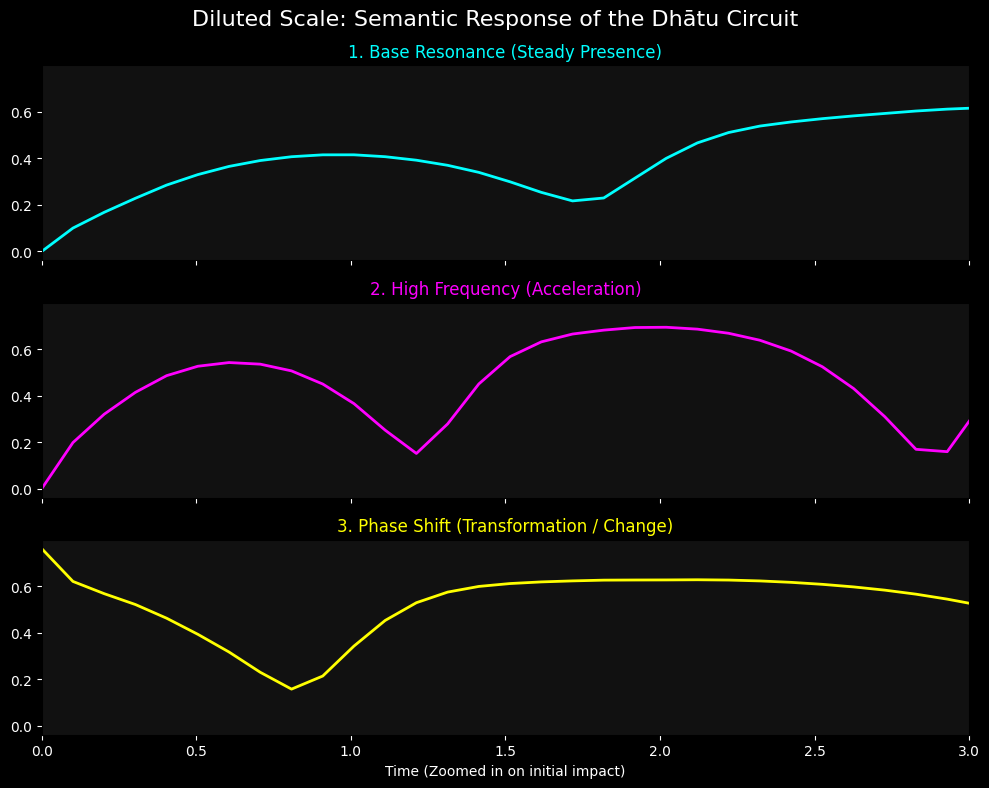

In [2]:
# ---------------------------------------------------------
# PHASE 3: SEMANTIC PROBING (Testing the Extracted Dhātu)
# ---------------------------------------------------------
# Identify the core nodes of our winning ticket (The Dhātu Circuit)
active_node_indices = torch.where(torch.sum(torch.abs(model.W), dim=0) > 0.05)[0]
print(f"Isolated Dhātu Circuit contains {len(active_node_indices)} core nodes.")

# Create probing stimuli (Different geometric intents)
t_probe = torch.linspace(0, 10, 100).to(device)

stimulus_base  = torch.sin(t_probe).unsqueeze(1).repeat(1, 64)   # Base sine
stimulus_fast  = torch.sin(2 * t_probe).unsqueeze(1).repeat(1, 64) # Double frequency
stimulus_shift = torch.cos(t_probe).unsqueeze(1).repeat(1, 64)   # Phase shift

# Probe function
def probe_network(stimulus):
    x_state = torch.zeros(1, 64).to(device)
    activations = []
    with torch.no_grad():
        for i in range(stimulus.size(0)):
            x_state = model(x_state, stimulus[i])
            if len(active_node_indices) > 0:
                circuit_energy = torch.mean(torch.abs(x_state[0, active_node_indices])).item()
            else:
                circuit_energy = 0.0
            activations.append(circuit_energy)
    return activations

# Run probes
response_base  = probe_network(stimulus_base)
response_fast  = probe_network(stimulus_fast)
response_shift = probe_network(stimulus_shift)

# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, sharey=True)
fig.patch.set_facecolor('black')
fig.suptitle("Diluted Scale: Semantic Response of the Dhātu Circuit", color="white", size=16)

time_data = t_probe.cpu().numpy()

# Chart 1: Base Sine
axes[0].plot(time_data, response_base, color="cyan", linewidth=2)
axes[0].set_title("1. Base Resonance (Steady Presence)", color="cyan")
axes[0].set_facecolor('#111111')
axes[0].tick_params(colors='white')

# Chart 2: Fast Sine
axes[1].plot(time_data, response_fast, color="magenta", linewidth=2)
axes[1].set_title("2. High Frequency (Acceleration)", color="magenta")
axes[1].set_facecolor('#111111')
axes[1].tick_params(colors='white')

# Chart 3: Cosine
axes[2].plot(time_data, response_shift, color="yellow", linewidth=2)
axes[2].set_title("3. Phase Shift (Transformation / Change)", color="yellow")
axes[2].set_facecolor('#111111')
axes[2].tick_params(colors='white')

# Zoom in on first 3 time steps
axes[2].set_xlim(0, 3)
axes[2].set_xlabel("Time (Zoomed in on initial impact)", color="white")

plt.tight_layout()
plt.show()

In [3]:
# ---------------------------------------------------------
# 7. Vaikharī Binding (Speech Translation Layer)
# ---------------------------------------------------------
def vaikharī_translate(circuit_energy: float) -> str:
    if circuit_energy > 0.5:
        return "Transformation"
    elif circuit_energy > 0.05:
        return "Presence"
    else:
        return "[Silence]"

peak_energy_shift = max(response_shift)
output_token = vaikharī_translate(peak_energy_shift)
print(f"Vaikharī Output for Phase Shift Probe: {output_token}")

Vaikharī Output for Phase Shift Probe: Transformation


In [4]:
# ---------------------------------------------------------
# PHASE 4: THE SANDHI EXPERIMENT (Multi-Attractor Substrate)
# ---------------------------------------------------------

# 1. Expand the Brain to 128 Dimensions to hold two concepts
class DualResonanceModel(nn.Module):
    def __init__(self, hidden_dim=128):  
        super().__init__()
        # Initialize dense, we will prune it later
        self.W = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
    
    def forward(self, x, stimulus):
        return torch.tanh(torch.matmul(x, self.W) + stimulus)

dual_model = DualResonanceModel().to(device)
dual_optimizer = torch.optim.Adam(dual_model.parameters(), lr=1e-3)

# ---------------------------------------------------------
# 2. Generate the Dual Training Data (CORRECTED)
# ---------------------------------------------------------
seq_len = 100
t_dual = torch.linspace(0, 10, seq_len).to(device)

stimulus_gam = torch.cos(t_dual).unsqueeze(1).repeat(1, 128)
stimulus_stha = torch.sin(t_dual).unsqueeze(1).repeat(1, 128)

# FIX: Map targets to natural waves capped at 0.8 amplitude.
# This prevents the tanh() weight-explosion.
target_gam = torch.zeros(seq_len, 128).to(device)
target_gam[:, :64] = torch.cos(t_dual).unsqueeze(1).repeat(1, 64) * 0.8 

target_stha = torch.zeros(seq_len, 128).to(device)
target_stha[:, 64:] = torch.sin(t_dual).unsqueeze(1).repeat(1, 64) * 0.8

# 3. The Multi-Objective Training Loop
epochs_dual = 500
print("Initiating Multi-Attractor Sandhi Training...")

for epoch in range(epochs_dual + 1):
    dual_optimizer.zero_grad()
    
    # Train GAM (Transformation)
    x_gam = torch.zeros(1, 128).to(device)
    loss_gam_task = 0.0
    for i in range(seq_len):
        x_gam = dual_model(x_gam, stimulus_gam[i])
        loss_gam_task += F.mse_loss(x_gam, target_gam[i].unsqueeze(0))
        
    # Train STHA (Stability)
    x_stha = torch.zeros(1, 128).to(device)
    loss_stha_task = 0.0
    for i in range(seq_len):
        x_stha = dual_model(x_stha, stimulus_stha[i])
        loss_stha_task += F.mse_loss(x_stha, target_stha[i].unsqueeze(0))

    # The Unified Friston Loss
    total_friston = loss_gam_task + loss_stha_task

# Prāṇa Penalty (Mean of both states)
    loss_prana = 0.005 * (torch.mean(torch.abs(x_gam)) + torch.mean(torch.abs(x_stha)))
    
    # Structural Penalty (Increased for the 128-dim matrix)
    loss_dhatu = 0.005 * torch.sum(torch.abs(dual_model.W))
    
    # Biological Pruning Schedule
    if epoch < 200:
        total_loss = total_friston
    else:
        total_loss = total_friston + loss_prana + loss_dhatu
        
    total_loss.backward()
    dual_optimizer.step()
    
    if epoch % 100 == 0:
        active = torch.count_nonzero(torch.abs(dual_model.W) > 0.01).item()
        print(f"Epoch {epoch} | Total Task Loss: {total_friston.item():.2f} | Active Synapses: {active}")

print("Multi-Attractor Substrate Finalized.")

Initiating Multi-Attractor Sandhi Training...
Epoch 0 | Total Task Loss: 32.89 | Active Synapses: 5243
Epoch 100 | Total Task Loss: 16.90 | Active Synapses: 7689
Epoch 200 | Total Task Loss: 16.57 | Active Synapses: 8768
Epoch 300 | Total Task Loss: 16.54 | Active Synapses: 7039
Epoch 400 | Total Task Loss: 16.53 | Active Synapses: 6282
Epoch 500 | Total Task Loss: 16.51 | Active Synapses: 5865
Multi-Attractor Substrate Finalized.


Initiating Sandhi Collision Protocol...


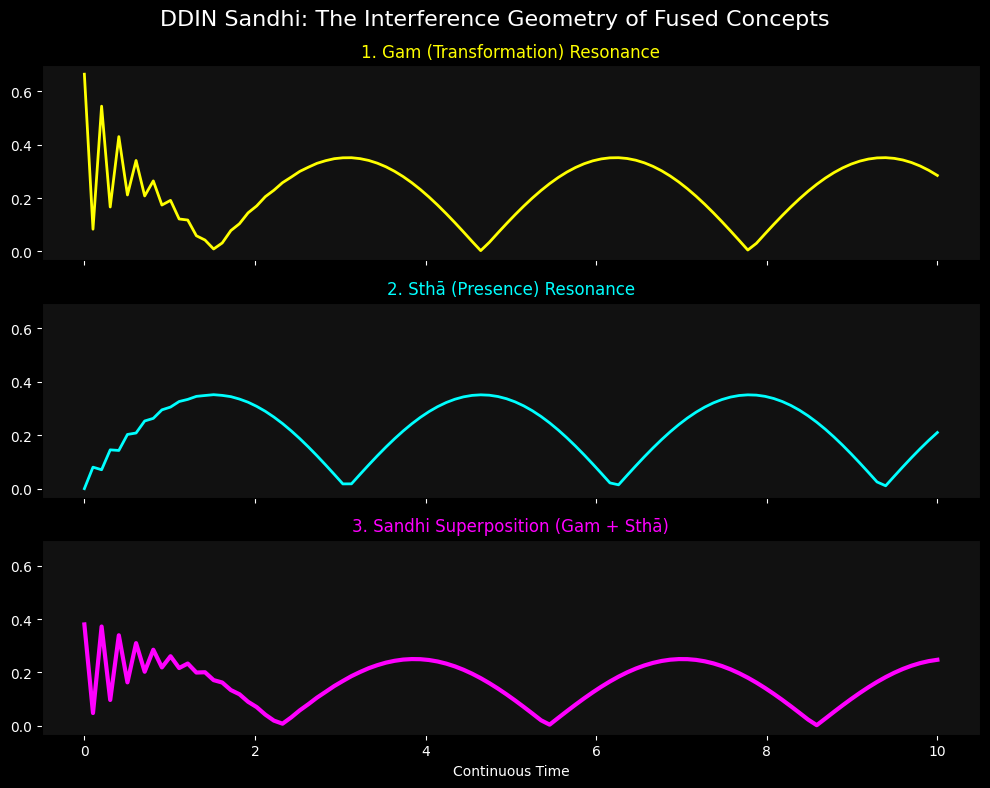

In [5]:
# ---------------------------------------------------------
# PHASE 5: THE SANDHI COLLISION (Wave Interference)
# ---------------------------------------------------------
print("Initiating Sandhi Collision Protocol...")

# 1. Isolate the surviving global network structure
active_nodes_dual = torch.where(torch.sum(torch.abs(dual_model.W), dim=0) > 0.05)[0]

# 2. Create the collision stimulus (Superposition of both waves)
t_probe = torch.linspace(0, 10, 100).to(device)
probe_gam = torch.cos(t_probe).unsqueeze(1).repeat(1, 128) * 0.8
probe_stha = torch.sin(t_probe).unsqueeze(1).repeat(1, 128) * 0.8

# THE SANDHI: We literally add the two physical signals together
probe_sandhi = (probe_gam + probe_stha) / 2.0 

# 3. Probe Function
def probe_dual_network(stimulus):
    x_state = torch.zeros(1, 128).to(device)
    activations = []
    with torch.no_grad():
        for i in range(100):
            x_state = dual_model(x_state, stimulus[i])
            if len(active_nodes_dual) > 0:
                # Measure the energy of the whole 128-dim brain
                total_energy = torch.mean(torch.abs(x_state[0, active_nodes_dual])).item()
            else:
                total_energy = 0
            activations.append(total_energy)
    return activations

# 4. Run the isolated and collided probes
res_gam_only = probe_dual_network(probe_gam)
res_stha_only = probe_dual_network(probe_stha)
res_sandhi = probe_dual_network(probe_sandhi)

# ---------------------------------------------------------
# VISUALIZE THE SANDHI
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, sharey=True)
fig.patch.set_facecolor('black')
fig.suptitle("DDIN Sandhi: The Interference Geometry of Fused Concepts", color="white", size=16)

time_data = t_probe.cpu().numpy()

# Chart 1: Gam Only
axes[0].plot(time_data, res_gam_only, color="yellow", linewidth=2)
axes[0].set_title("1. Gam (Transformation) Resonance", color="yellow")
axes[0].set_facecolor('#111111')
axes[0].tick_params(colors='white')

# Chart 2: Stha Only
axes[1].plot(time_data, res_stha_only, color="cyan", linewidth=2)
axes[1].set_title("2. Sthā (Presence) Resonance", color="cyan")
axes[1].set_facecolor('#111111')
axes[1].tick_params(colors='white')

# Chart 3: The Sandhi Collision
axes[2].plot(time_data, res_sandhi, color="magenta", linewidth=3)
axes[2].set_title("3. Sandhi Superposition (Gam + Sthā)", color="magenta")
axes[2].set_facecolor('#111111')
axes[2].tick_params(colors='white')
axes[2].set_xlabel("Continuous Time", color="white")

plt.tight_layout()
plt.show()